<a href="https://colab.research.google.com/github/Rupikareddy19/Final_year_Major_Project-/blob/main/major_prjct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
# ---------------------------
# USER SETTINGS
# ---------------------------

TIME_STEP = 15
EPOCHS = 200
BATCH_SIZE = 32

# Mode (univariate or multivariate)
MODE = "univariate"

In [4]:
# ---------------------------
# Helper Function
# ---------------------------

def create_sequences(X_array, y_array, time_step=15):
    Xs, ys = [], []

    for i in range(time_step, len(X_array)):
        Xs.append(X_array[i-time_step:i])
        ys.append(y_array[i])

    return np.array(Xs), np.array(ys)

In [14]:
# ---------------------------
# Load Dataset
# ---------------------------

# Change the path value to the folder where your dataset is stored
# Terminate the path value with \\

path = "/content/" # Corrected path to be the directory
csv_file = "BTC_USD_data.csv"

df = pd.read_csv(path + csv_file)

print("Loaded data shape:", df.shape)
print("Columns:", list(df.columns))

Loaded data shape: (4093, 7)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [15]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce")

df = df.dropna(subset=["Date"]).reset_index(drop=True)

df = df.sort_values("Date").reset_index(drop=True)

numeric_cols = ["Open","High","Low","Close","Adj Close","Volume"]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[numeric_cols] = df[numeric_cols].ffill().bfill()

df = df[(df["High"] >= df["Low"]) & (df["Close"] > 0)].reset_index(drop=True)

print("\nAfter preprocessing shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())


After preprocessing shape: (4093, 7)

Missing values per column:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [16]:
df["Close lag1"] = df["Close"].shift(1)

df["Close MA7"] = df["Close"].rolling(window=7).mean()
df["Close MA30"] = df["Close"].rolling(window=30).mean()

df["Close pct change"] = df["Close"].pct_change() * 100

df["HL range"] = df["High"] - df["Low"]
df["HL pct"] = (df["High"] - df["Low"]) / df["Close"] * 100

df["Volume MA7"] = df["Volume"].rolling(window=7).mean()
df["Volume pct change"] = df["Volume"].pct_change() * 100

engineered_cols = [
"Close lag1","Close MA7","Close MA30",
"Close pct change","HL range","HL pct",
"Volume MA7","Volume pct change"
]

df[engineered_cols] = df[engineered_cols].ffill().bfill()

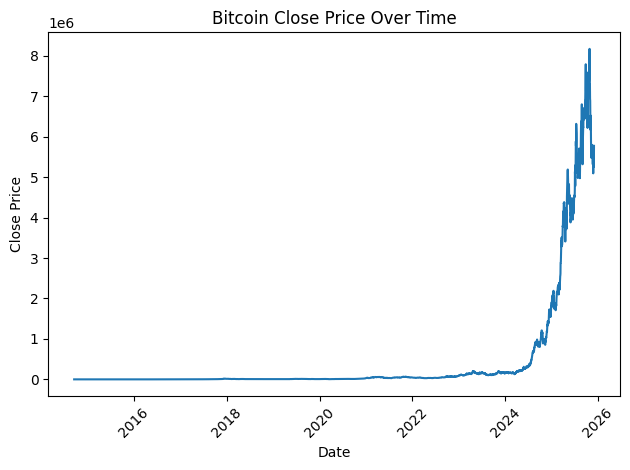

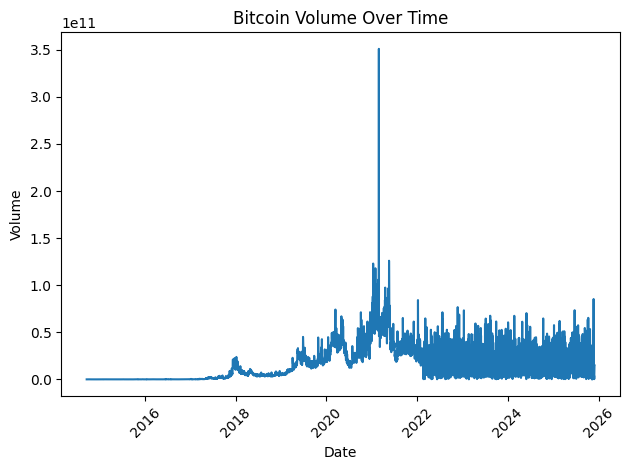

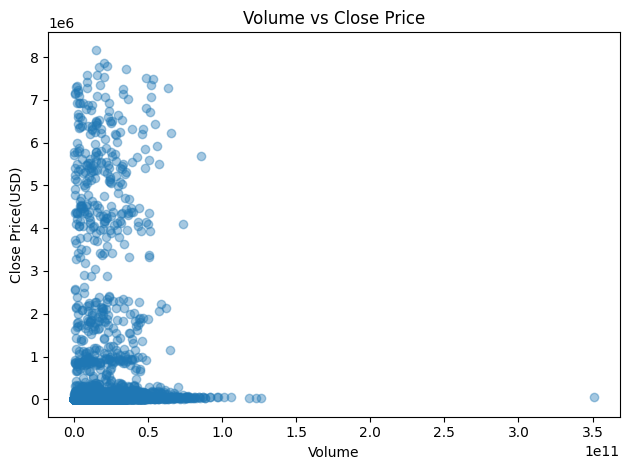

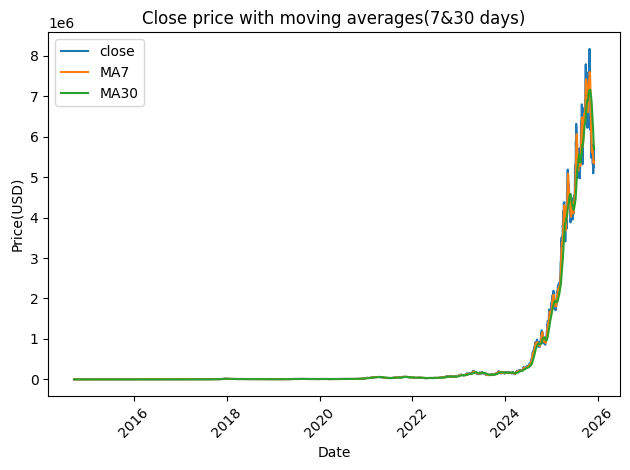

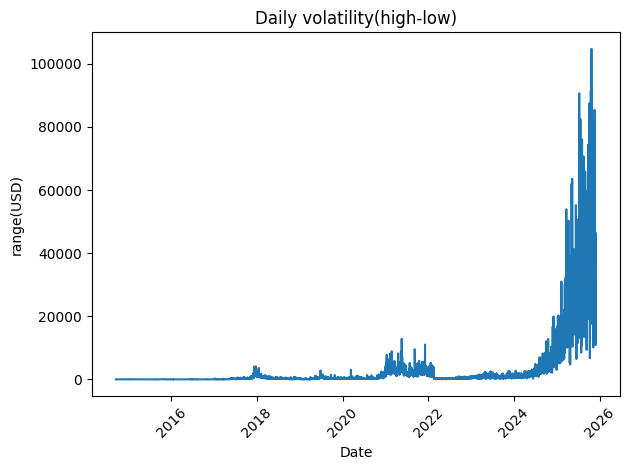

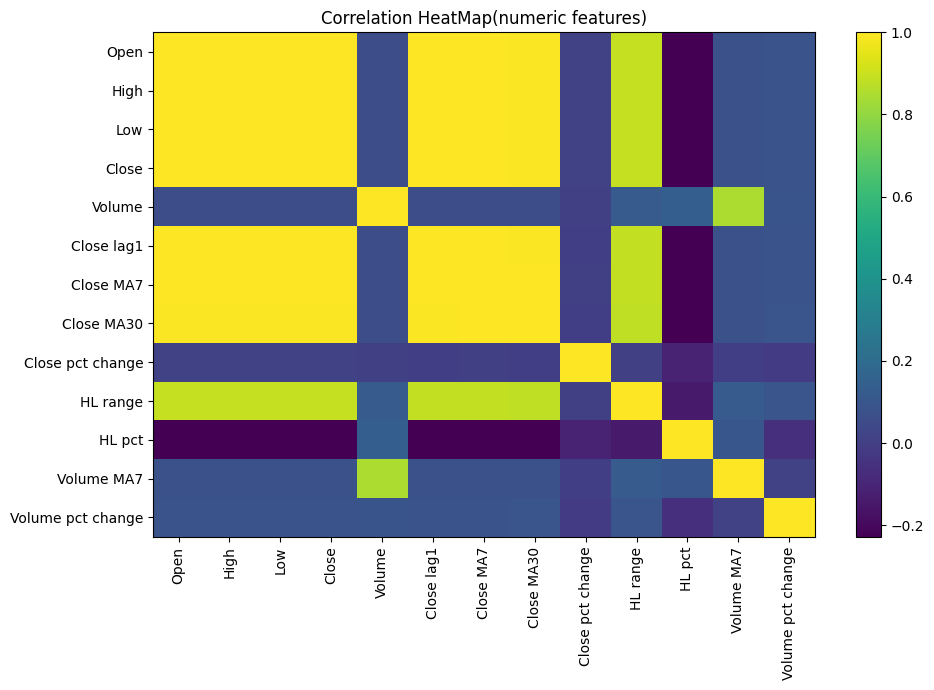

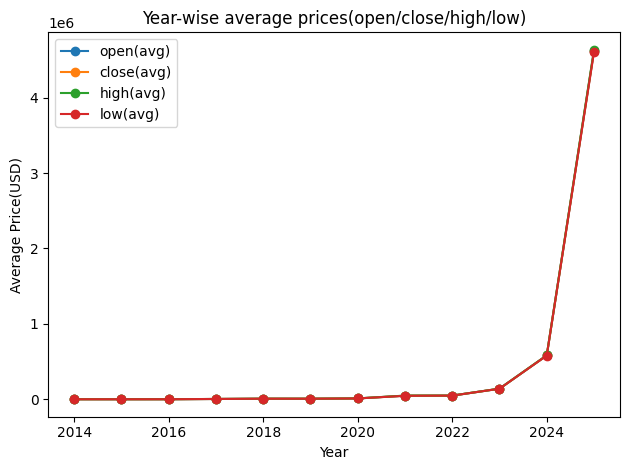

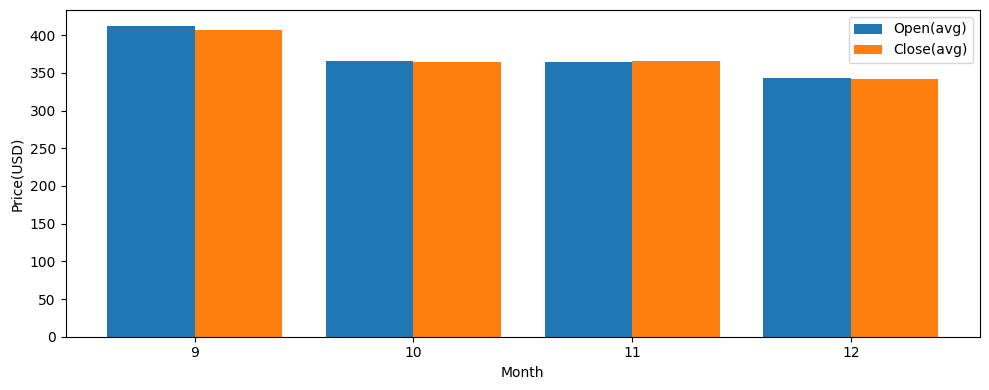

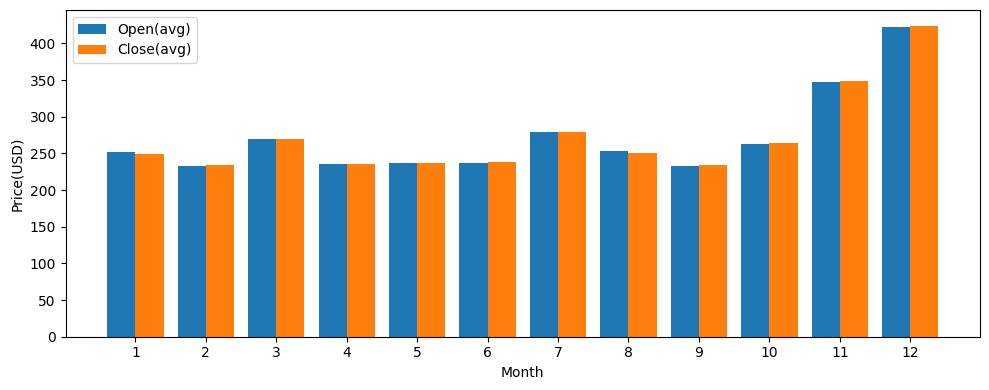

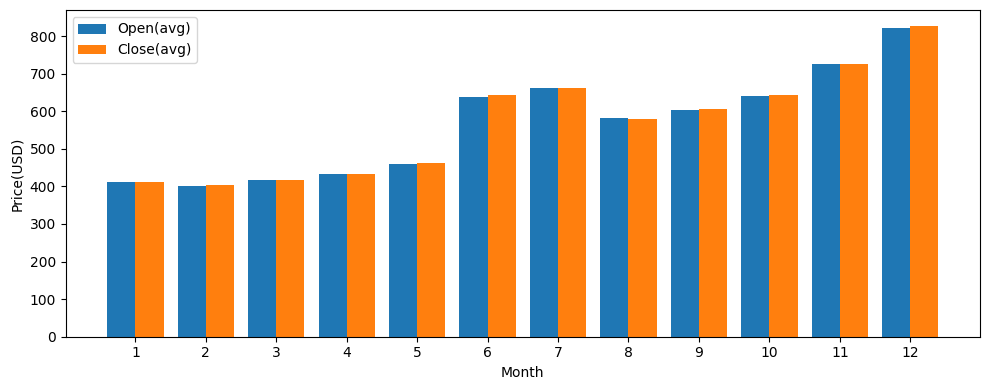

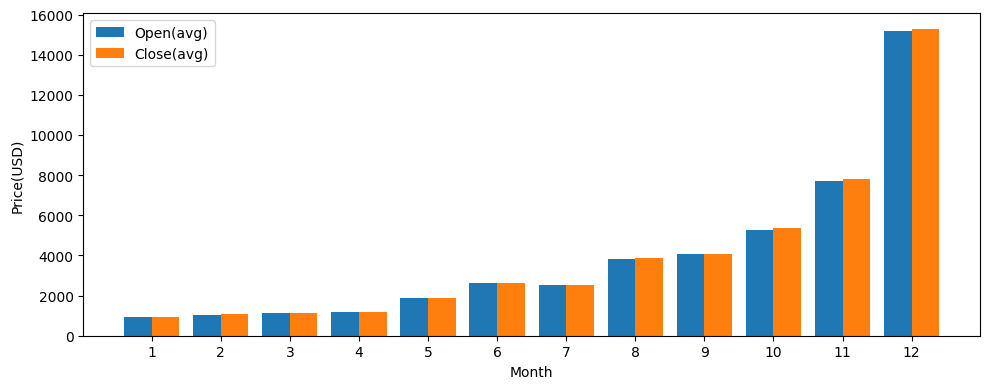

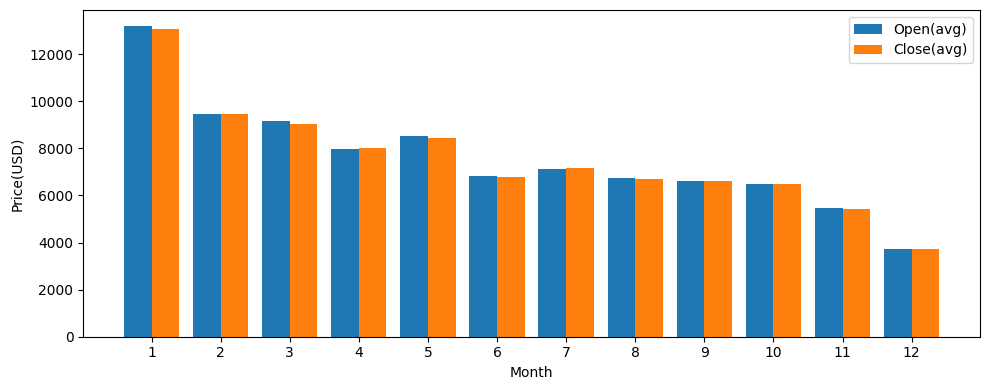

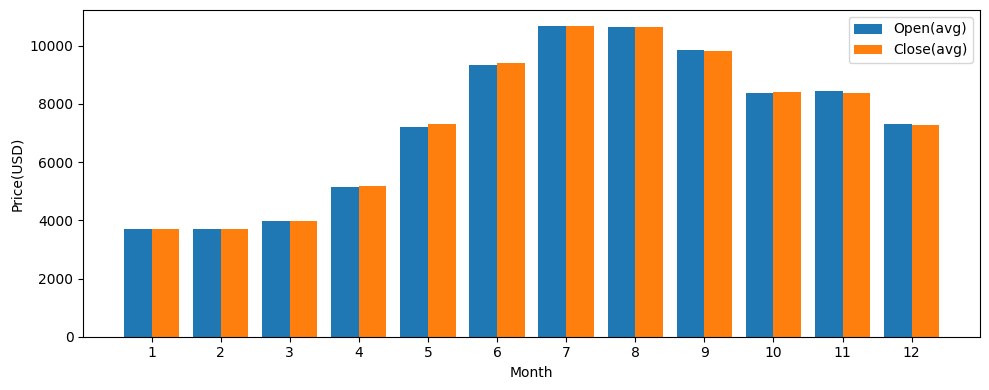

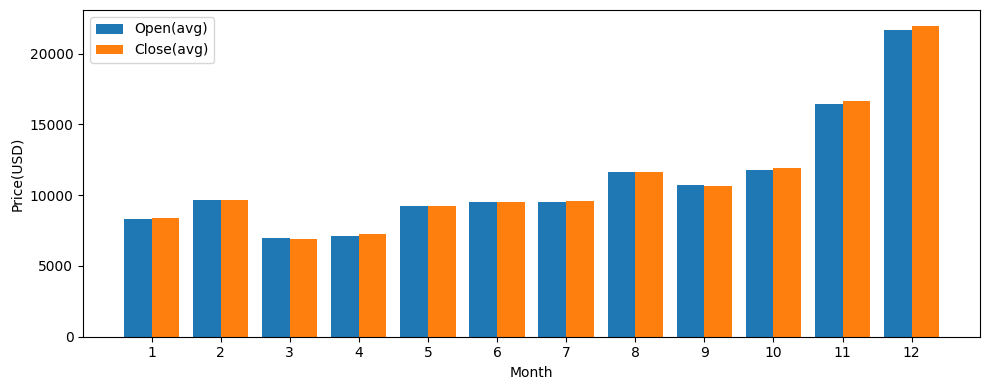

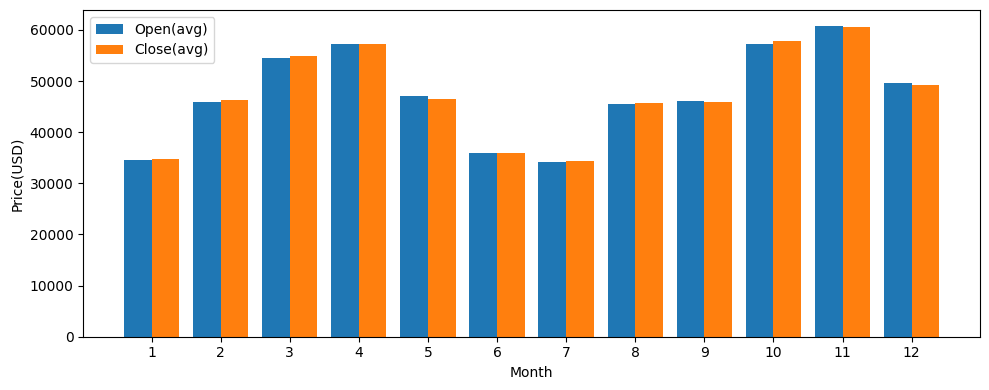

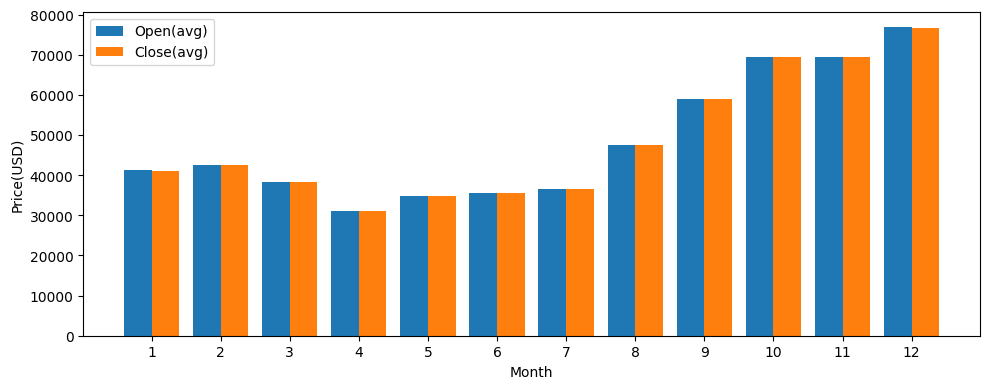

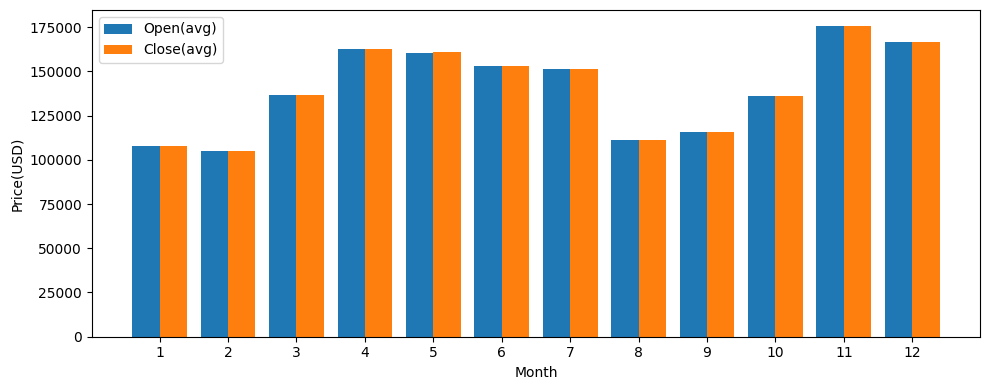

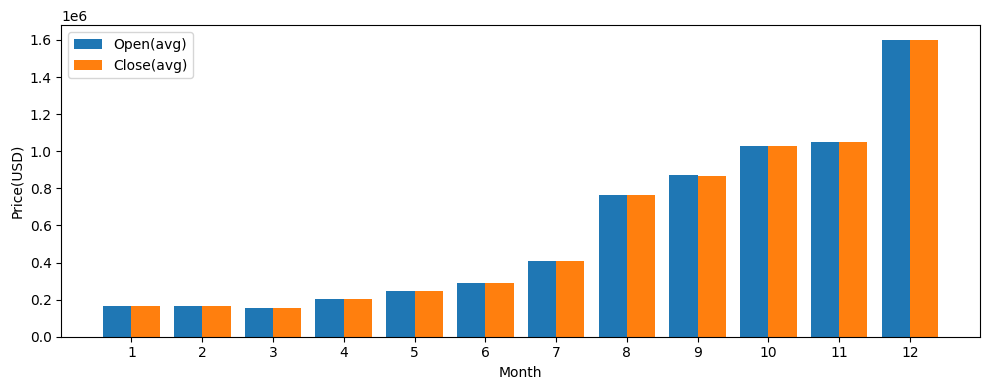

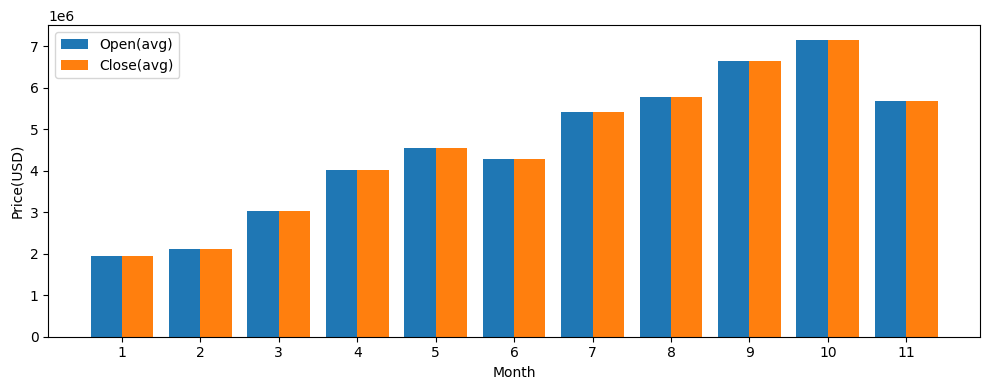

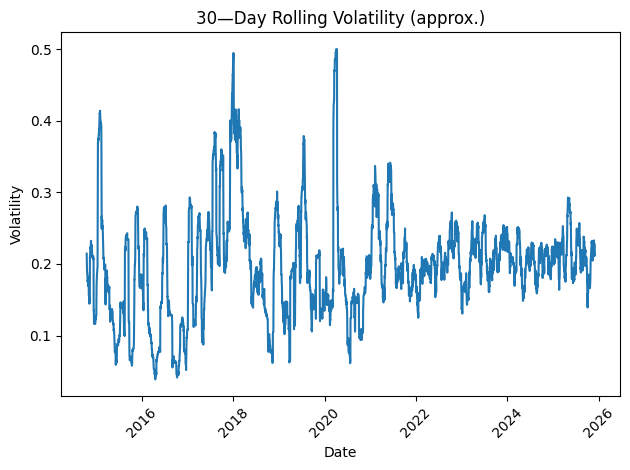

In [33]:
from pandas.core.indexing import convert_from_missing_indexer_tuple
plt.figure()
plt.plot(df["Date"], df["Close"])
plt.title("Bitcoin Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.figure()
plt.plot(df["Date"], df["Volume"])
plt.title("Bitcoin Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.figure()
plt.scatter(df["Volume"], df["Close"],alpha=0.4)
plt.title("Volume vs Close Price")
plt.xlabel("Volume")
plt.ylabel("Close Price(USD)")
plt.tight_layout()
plt.show()
plt.figure()
plt.plot(df["Date"], df["Close"],label="close")
plt.plot(df["Date"], df["Close MA7"],label="MA7")
plt.plot(df["Date"], df["Close MA30"],label="MA30")
plt.title("Close price with moving averages(7&30 days)")
plt.xlabel("Date")
plt.ylabel("Price(USD)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.figure()
plt.plot(df["Date"], df["HL range"])
plt.title("Daily volatility(high-low)")
plt.xlabel("Date")
plt.ylabel("range(USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
corr_cols=["Open","High","Low","Close","Volume","Close lag1","Close MA7","Close MA30","Close pct change","HL range","HL pct",
"Volume MA7","Volume pct change"]
corr=df[corr_cols].corr()
plt.figure(figsize=(10,7))
plt.imshow(corr,aspect="auto")
plt.title("Correlation HeatMap(numeric features)")
plt.xticks(range(len(corr_cols)),corr_cols,rotation=90)
plt.yticks(range(len(corr_cols)),corr_cols)
plt.colorbar()
plt.tight_layout()
plt.show()
df["year"]=df["Date"].dt.year
df["month"]=df["Date"].dt.month
yearly=df.groupby("year")[["Open","Close","High","Low"]].mean()
plt.figure()
plt.plot(yearly.index,yearly["Open"],marker="o",label="open(avg)")
plt.plot(yearly.index,yearly["Close"],marker="o",label="close(avg)")
plt.plot(yearly.index,yearly["High"],marker="o",label="high(avg)")
plt.plot(yearly.index,yearly["Low"],marker="o",label="low(avg)")
plt.title("Year-wise average prices(open/close/high/low)")
plt.xlabel("Year")
plt.ylabel("Average Price(USD)")
plt.legend()
plt.tight_layout()
plt.show()
years=sorted(df["year"].unique())
for y in years:
    temp=df[df["year"]==y].groupby("month")[["Open","Close"]].mean()
    if temp.shape[0]==0:
        continue
    plt.figure(figsize=(10,4))
    x=np.arange(len(temp.index))
    width=0.4
    plt.bar(x - width/2, temp["Open"].values, width=width, label="Open(avg)")
    plt.bar(x+width/2,temp["Close"].values, width=width,
            label = "Close(avg)")
    plt.xlabel("Month")
    plt.ylabel("Price(USD)")
    plt.xticks(x,temp.index)
    plt.legend()
    plt.tight_layout()
    plt.show()
    df["Close_return"]=df["Close"].pct_change ()
df["Volatility_30"]=df["Close_return"].rolling(30).std()*np.sqrt(30)
plt.figure()
plt.plot(df["Date"],df["Volatility_30"])
plt.title("30—Day Rolling Volatility (approx.)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [34]:
if MODE.lower() == "univariate":
    feature_cols = ["Close"]
else:
    feature_cols = [
    "Open","High","Low","Close","Volume",
    "Close lag1","Close MA7","Close MA30",
    "Close pct change","HL range","HL pct",
    "Volume MA7","Volume pct change"
    ]

print("MODE:", MODE)
print("Using features:", feature_cols)

X_raw = df[feature_cols].values.astype(float)
y_raw = df["Close"].values.astype(float).reshape(-1,1)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)
split_index = int(len(df)*0.80)

X_train_raw = X_scaled[:split_index]
X_test_raw = X_scaled[split_index:]

y_train_raw = y_scaled[:split_index]
y_test_raw = y_scaled[split_index:]
X_train, y_train = create_sequences(X_train_raw, y_train_raw, TIME_STEP)
X_test, y_test = create_sequences(X_test_raw, y_test_raw, TIME_STEP)

print("X train:", X_train.shape)
print("y train:", y_train.shape)

print("X test:", X_test.shape)
print("y test:", y_test.shape)

MODE: univariate
Using features: ['Close']
X train: (3259, 15, 1)
y train: (3259, 1)
X test: (804, 15, 1)
y test: (804, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 8.4744e-06 - val_loss: 0.1036
Epoch 2/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.0202e-07 - val_loss: 0.0859
Epoch 3/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.3798e-07 - val_loss: 0.0864
Epoch 4/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3576e-07 - val_loss: 0.0869
Epoch 5/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4664e-07 - val_loss: 0.0873
Epoch 6/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4749e-07 - val_loss: 0.0872
Epoch 7/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4774e-07 - val_loss: 0.0874
Epoch 8/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4490e-07 - val_loss: 0.0875
Epoch 9/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.5185e-07 - val_loss: 0.0874
Epoch 10/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4218e-07 - val_loss: 0.0876
Epoch 11/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4730e-07 - val_loss: 0

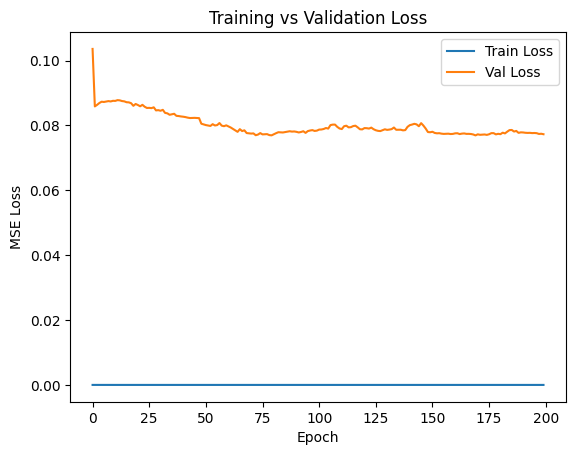

In [35]:
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential()

model.add(LSTM(10, activation="relu", input_shape=(TIME_STEP, X_train.shape[2])))
model.add(Dense(1))

model.compile(loss="mean_squared_error", optimizer="adam")

model.summary()
history = model.fit(
X_train,
y_train,
validation_data=(X_test,y_test),
epochs=EPOCHS,
batch_size=BATCH_SIZE,
verbose=1
)
plt.figure()

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.show()

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


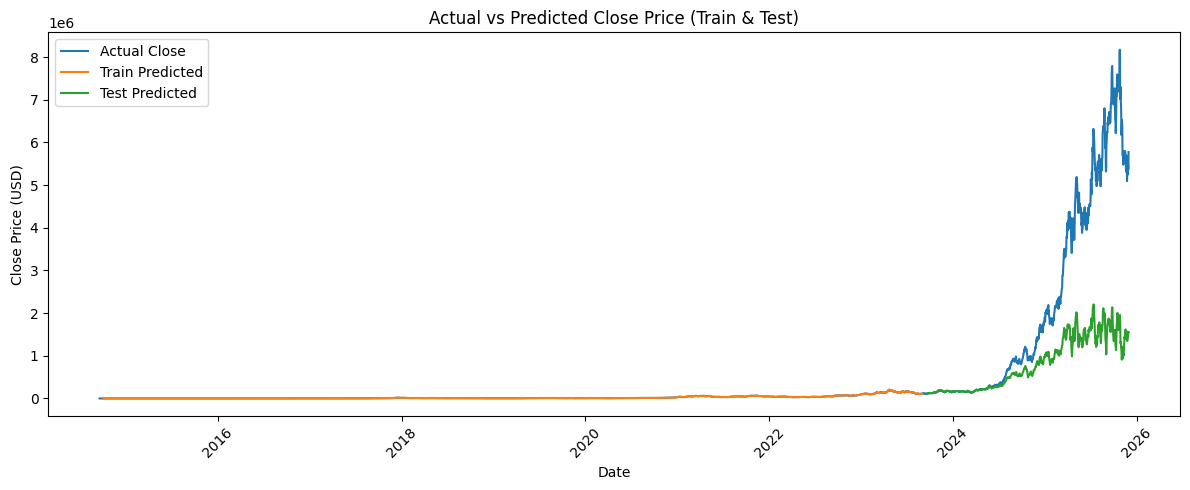

In [36]:
# Predictions (train/test) + plots

train_pred_scaled = model.predict(X_train)
test_pred_scaled = model.predict(X_test)

train_pred = scaler_y.inverse_transform(train_pred_scaled)
test_pred = scaler_y.inverse_transform(test_pred_scaled)

# Build aligned arrays for plotting

train_plot = np.empty((split_index, 1))
train_plot[:] = np.nan
train_plot[TIME_STEP:] = train_pred

test_plot = np.empty((len(df) - split_index, 1))
test_plot[:] = np.nan
test_plot[TIME_STEP:] = test_pred

plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Close"], label="Actual Close")

plt.plot(df["Date"][:split_index], train_plot, label="Train Predicted")

plt.plot(df["Date"][split_index:], test_plot, label="Test Predicted")

plt.title("Actual vs Predicted Close Price (Train & Test)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


Forecasting next 30 days (Iterative multi-step)


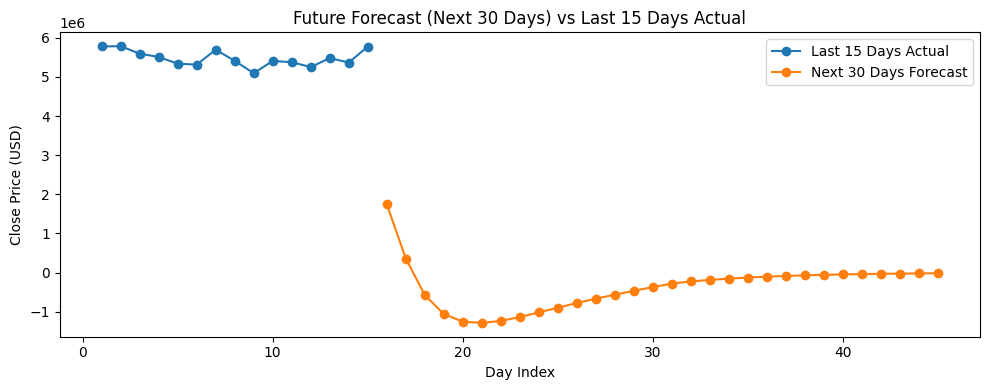


Next 30 forecasted closing prices (USD) - first 10 shown:
[ 1744003.2    358808.38  -574688.25 -1060851.5  -1253563.8  -1285746.2
 -1234621.9  -1135953.   -1018247.25  -895232.6 ]


In [37]:
# Future Forecast (Next 30 days) - iterative multi-step

print("\nForecasting next 30 days (Iterative multi-step)")

# For a realistic 30-day forecast, we use close-only data (univariate)
# because future OHLCV is unknown.

close_series = df["Close"].values.reshape(-1, 1)

close_scaler = MinMaxScaler((0,1))
close_scaled = close_scaler.fit_transform(close_series)

# If MODE is univariate reuse trained model
if MODE.lower() == "univariate":
    forecast_model = model
else:
    Xc, yc = create_sequences(close_scaled, close_scaled, TIME_STEP)

    split_c = int(len(Xc) * 0.80)

    Xc_train, yc_train = Xc[:split_c], yc[:split_c]
    Xc_test, yc_test = Xc[split_c:], yc[split_c:]

    forecast_model = Sequential()
    forecast_model.add(LSTM(10, activation="relu", input_shape=(TIME_STEP,1)))
    forecast_model.add(Dense(1))

    forecast_model.compile(loss="mean_squared_error", optimizer="adam")

    forecast_model.fit(
        Xc_train,
        yc_train,
        validation_data=(Xc_test, yc_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

# Start from last 15 days
last_window = close_scaled[-TIME_STEP:].reshape(1, TIME_STEP, 1)

future_scaled = []

for i in range(30):

    next_scaled = forecast_model.predict(last_window, verbose=0)[0][0]

    future_scaled.append(next_scaled)

    # Slide the window (drop first, append new prediction)
    new_window = np.append(last_window.flatten()[1:], next_scaled)

    last_window = new_window.reshape(1, TIME_STEP, 1)

future_scaled = np.array(future_scaled).reshape(-1,1)

future_prices = close_scaler.inverse_transform(future_scaled).flatten()

# Plot Future Forecast vs Last 15 Actual

last_15_actual = df["Close"].values[-TIME_STEP:]

plt.figure(figsize=(10,4))

plt.plot(range(1, TIME_STEP+1), last_15_actual, marker="o", label="Last 15 Days Actual")

plt.plot(range(TIME_STEP+1, TIME_STEP+31), future_prices, marker="o", label="Next 30 Days Forecast")

plt.title("Future Forecast (Next 30 Days) vs Last 15 Days Actual")
plt.xlabel("Day Index")
plt.ylabel("Close Price (USD)")

plt.legend()
plt.tight_layout()

plt.show()

print("\nNext 30 forecasted closing prices (USD) - first 10 shown:")
print(np.round(future_prices[:10], 2))

In [38]:
# Sample prediction component (next-day close)

print("\nSAMPLE PREDICTION:")

print("Provide last 15 days Close values to predict the next-day Close.\n")

# Example: using last 15 actual values
sample_close_15days = last_15_actual.tolist()

# Scale the values
sample_scaled = close_scaler.transform(np.array(sample_close_15days).reshape(-1,1))

# Reshape for LSTM input
sample_X = sample_scaled.reshape(1, TIME_STEP, 1)

# Predict next-day value
next_day_scaled = forecast_model.predict(sample_X, verbose=0)

# Convert back to original price
next_day_price = close_scaler.inverse_transform(next_day_scaled)[0][0]

print("Predicted next-day closing price (USD):", round(float(next_day_price), 2))


SAMPLE PREDICTION:
Provide last 15 days Close values to predict the next-day Close.

Predicted next-day closing price (USD): 1744003.25
